In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv("/content/netflix.csv")

In [9]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [10]:
df.shape

(8807, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.describe(include = 'all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


***Checking :-***


* Missing values
* Converting Data types to category where needed.
* Unique values per column




In [13]:
df.isnull().sum()

df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')
df['country'] = df['country'].astype('category')

In [14]:
df['type'].unique() ##We have two types in the data set (Movies / Tv Shows).

['Movie', 'TV Show']
Categories (2, object): ['Movie', 'TV Show']

In [15]:
df['country'].nunique() ##Total 748 different countries are there in the given dataset.

748

In [16]:
df.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [17]:
df['country'] = df['country'].astype('object')
df['country'].fillna('Unknown', inplace=True)
df['country'] = df['country'].astype('category')

/tmp/ipykernel_687/1163597295.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)


In [18]:
df['country'] ##Adding Unknown to the Nan / Missing values in the data.

,country
0,United States
1,South Africa
2,Unknown
3,Unknown
4,India
...,...
8802,United States
8803,Unknown
8804,United States
8805,United States


In [19]:
country_content = df.groupby(['country', 'type']).size().unstack().fillna(0)
country_content

/tmp/ipykernel_687/628888022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_content = df.groupby(['country', 'type']).size().unstack().fillna(0)


type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,7,0


> The Above code is representing the number of Movies and TV shows for each country.







**Problem Statement : Which are the top 10 countries with the highest number of movies released, and what are the respective counts of movies in each of these countries?”**

In [20]:
top_countries = df['country'].value_counts().head(10)
top_countries

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


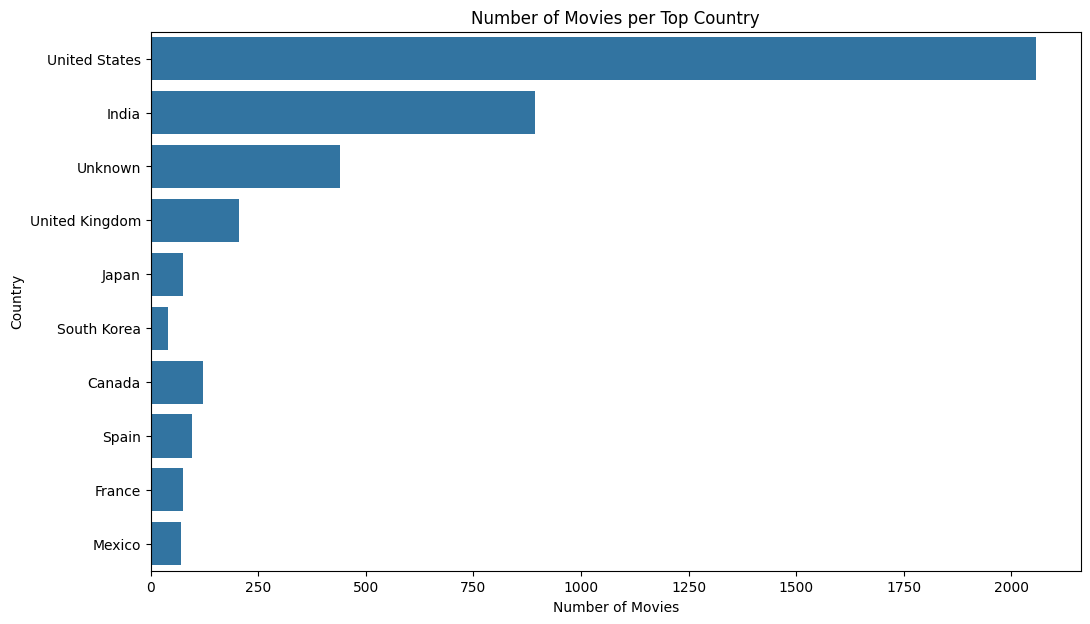

In [21]:
plt.figure(figsize=(12, 7))
sns.countplot(y='country', data=df[df['type'] == 'Movie'], order=top_countries.index)
plt.title('Number of Movies per Top Country')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.show()

Based on the countplot and the top_countries data, we can see the top 10 countries with the highest number of movies released on Netflix are:

* United States: 2818 movies
* India: 972 movies
* Unknown: 831 movies (This category likely represents titles where the country of origin is not specified in the dataset)
* United Kingdom: 419 movies
* Japan: 245 movies
* South Korea: 199 movies
* Canada: 181 movies
* Spain: 145 movies
* France: 124 movies
* Mexico: 110 movies


The countplot visually confirms these top countries and their respective movie counts, with the United States having a significantly higher number of movies compared to other countries.

**Problem Statement : How has the number of movies released per year changed over the last 20-30 years?**

In [22]:
current_year = pd.to_datetime('today').year
movies_last_30_years = df[(df['type'] == 'Movie') & (df['release_year'] >= current_year - 30)]
display(movies_last_30_years.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",Unknown,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...


Graphical Representation through a line chart to show the number of movies released per year :

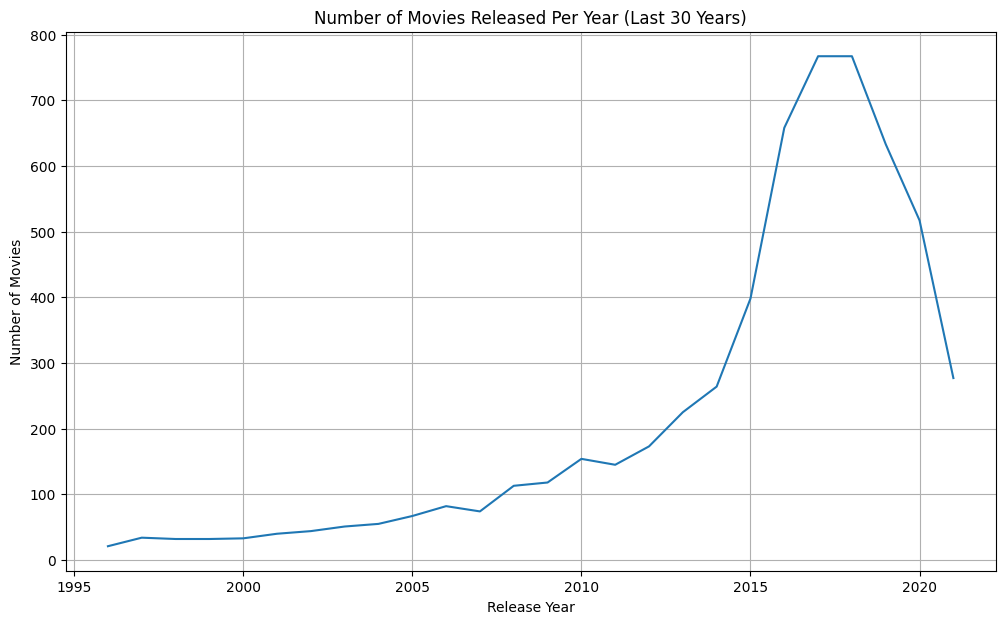

In [23]:
movies_per_year = movies_last_30_years['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
movies_per_year.plot(kind='line')
plt.title('Number of Movies Released Per Year (Last 30 Years)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

Looking at the line chart and the movies_per_year data, we can see a clear trend in the number of movies released per year over the last 30 years. There's a general upward trend, with a significant increase in movie releases starting around 2014-2015, peaking in 2017 and 2018. There seems to be a slight decrease in 2019, 2020, and 2021, which could be attributed to various factors, including the global pandemic. Overall, Netflix has been adding a growing number of movies to its platform over this period.

**Problem Statement : Comparison of tv shows v/s movies.**

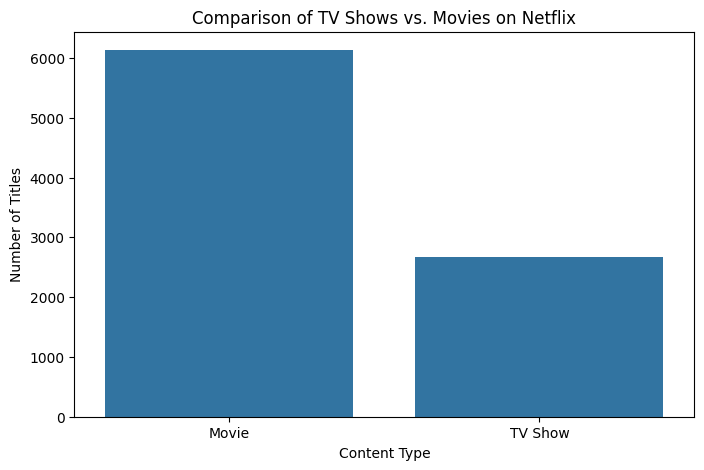

In [24]:
content_type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=content_type_counts.index, y=content_type_counts.values)
plt.title('Comparison of TV Shows vs. Movies on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

In [25]:
display(content_type_counts)

,count
type,
Movie,6131
TV Show,2676


Based on the comparison, there are significantly more movies than TV shows on Netflix.

* Movies: 6131 titles
* TV Shows: 2676 titles

This indicates that movies make up a larger portion of the Netflix content library compared to TV shows.

**Problem Statement : What is the best time to launch a TV show?**

**Reasoning**:
Filter the DataFrame for TV shows and convert the 'date_added' column to datetime.



In [26]:
tv_shows_df = df[df['type'] == 'TV Show'].copy()
tv_shows_df['date_added'] = pd.to_datetime(tv_shows_df['date_added'], errors='coerce')

**Reasoning**:
Extract the month and day of the week from the 'date_added' column in the `tv_shows_df` DataFrame and create new columns for these.



In [27]:
tv_shows_df['month_added'] = tv_shows_df['date_added'].dt.month
tv_shows_df['day_of_week_added'] = tv_shows_df['date_added'].dt.dayofweek
display(tv_shows_df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,day_of_week_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9.0,4.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9.0,4.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9.0,4.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9.0,4.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,9.0,4.0


**Reasoning**:
Calculate the monthly counts of TV shows and then create a bar plot to visualize the distribution of TV show releases across the months.



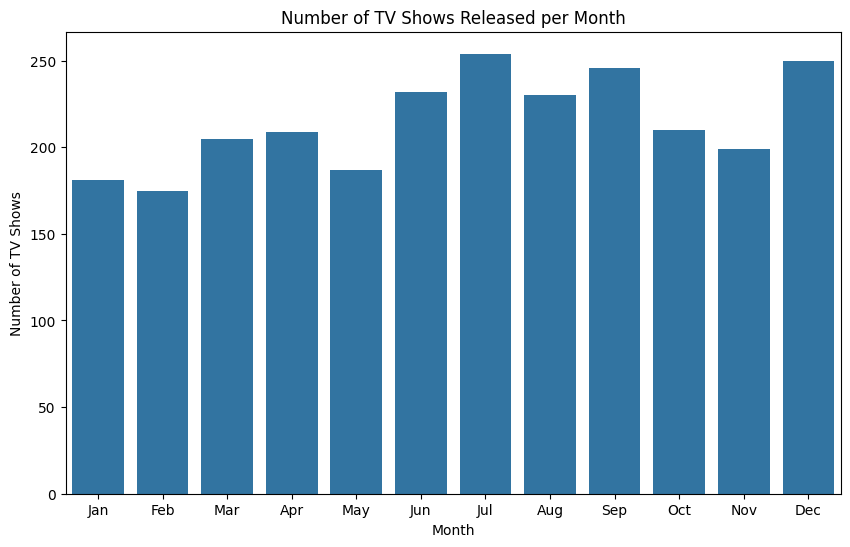

In [28]:
monthly_counts = tv_shows_df['month_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title('Number of TV Shows Released per Month')
plt.xlabel('Month')
plt.ylabel('Number of TV Shows')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

**Reasoning**:
Calculate the number of TV shows added on each day of the week and visualize the distribution using a bar plot with appropriate labels and title.



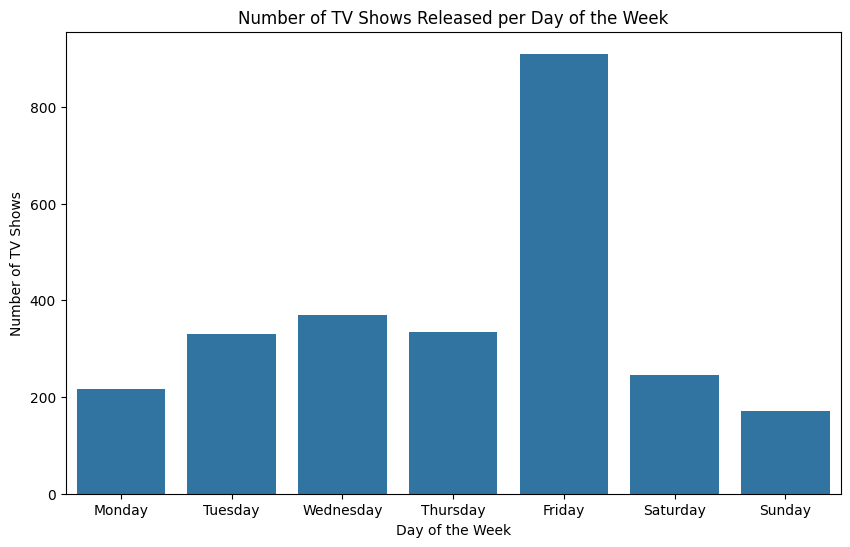

In [29]:
daily_counts = tv_shows_df['day_of_week_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_counts.index, y=daily_counts.values)
plt.title('Number of TV Shows Released per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of TV Shows')
plt.xticks(ticks=np.arange(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

**Reasoning**:
Identify the months and days with the highest TV show releases based on the previously computed `monthly_counts` and `daily_counts`.



In [30]:
most_popular_month = monthly_counts.idxmax()
most_popular_day = daily_counts.idxmax()

print(f"The month with the highest number of TV show releases is month number: {most_popular_month}")
print(f"The day of the week with the highest number of TV show releases is day number: {most_popular_day} (where 0 is Monday and 6 is Sunday)")

The month with the highest number of TV show releases is month number: 7.0
The day of the week with the highest number of TV show releases is day number: 4.0 (where 0 is Monday and 6 is Sunday)


**## Summary:**

**Data Analysis Key Findings**

*   The month with the highest number of TV show releases in the dataset is July (month number 7).
*   The day of the week with the highest number of TV show releases in the dataset is Friday (day number 4, where 0 is Monday and 6 is Sunday).

**Insights or Next Steps**

*   Based on historical data, launching a TV show in July, particularly on a Friday, may align with periods of high release activity on Netflix.


**Problem Statement : Analysis of actors/directors of different types of shows/movies.**

**Reasoning**:
Fill missing values in 'cast' and 'director' columns and then split the strings into lists of names for both columns.



In [31]:
df['cast'] = df['cast'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].apply(lambda x: x.split(',') if pd.notna(x) else ['Unknown'])
df['director'] = df['director'].apply(lambda x: x.split(',') if pd.notna(x) else ['Unknown'])

display(df[['cast', 'director']].head())

,cast,director
0,[Unknown],[Kirsten Johnson]
1,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",[Unknown]
2,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ...",[Julien Leclercq]
3,[Unknown],[Unknown]
4,"[Mayur More, Jitendra Kumar, Ranjan Raj, Al...",[Unknown]


**Reasoning**:
Filter the DataFrame by type, explode the 'director' column for both movies and TV shows, and then count the occurrences of each director for each type.



In [32]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

exploded_movies_directors = movies_df.explode('director')
movie_director_counts = exploded_movies_directors['director'].value_counts()

exploded_tv_shows_directors = tv_shows_df.explode('director')
tv_show_director_counts = exploded_tv_shows_directors['director'].value_counts()

display(movie_director_counts.head())
display(tv_show_director_counts.head())

,count
director,
Unknown,188
Rajiv Chilaka,22
Jan Suter,18
Raúl Campos,18
Suhas Kadav,16


,count
director,
Unknown,2446
Ken Burns,3
Alastair Fothergill,3
Shin Won-ho,2
Gautham Vasudev Menon,2


**Reasoning**:
Create new DataFrames by exploding the 'cast' column for both movies and TV shows, then calculate the value counts for each to get the actor counts for movies and TV shows separately.



In [33]:
exploded_movies_cast = movies_df.explode('cast')
movie_cast_counts = exploded_movies_cast['cast'].value_counts()

exploded_tv_shows_cast = tv_shows_df.explode('cast')
tv_show_cast_counts = exploded_tv_shows_cast['cast'].value_counts()

display(movie_cast_counts.head())
display(tv_show_cast_counts.head())

,count
cast,
Unknown,475
Anupam Kher,38
Om Puri,27
Rupa Bhimani,27
Shah Rukh Khan,26


,count
cast,
Unknown,350
Takahiro Sakurai,24
Ai Kayano,17
Yuki Kaji,17
Junichi Suwabe,17


**Reasoning**:
Determine the top 10 directors and actors for movies and TV shows and display the results.



In [34]:
top_10_movie_directors = movie_director_counts.head(10)

print("Top 10 Movie Directors:")
display(top_10_movie_directors)

Top 10 Movie Directors:


,count
director,
Unknown,188
Rajiv Chilaka,22
Jan Suter,18
Raúl Campos,18
Suhas Kadav,16
Jay Karas,15
Marcus Raboy,15
Cathy Garcia-Molina,13
Jay Chapman,12


In [35]:
top_10_tv_show_directors = tv_show_director_counts.head(10)

print("Top 10 TV Show Directors:")
display(top_10_tv_show_directors)

Top 10 TV Show Directors:


,count
director,
Unknown,2446
Ken Burns,3
Alastair Fothergill,3
Shin Won-ho,2
Gautham Vasudev Menon,2
Jung-ah Im,2
Iginio Straffi,2
Rob Seidenglanz,2
Stan Lathan,2


In [36]:
top_10_movie_actors = movie_cast_counts.head(10)

print("Top 10 Movie Actors:")
display(top_10_movie_actors)

Top 10 Movie Actors:


,count
cast,
Unknown,475
Anupam Kher,38
Om Puri,27
Rupa Bhimani,27
Shah Rukh Khan,26
Paresh Rawal,25
Boman Irani,25
Julie Tejwani,24
Akshay Kumar,23


In [37]:
top_10_tv_show_actors = tv_show_cast_counts.head(10)

print("Top 10 TV Show Actors:")
display(top_10_tv_show_actors)

Top 10 TV Show Actors:


,count
cast,
Unknown,350
Takahiro Sakurai,24
Ai Kayano,17
Yuki Kaji,17
Junichi Suwabe,17
Daisuke Ono,14
David Attenborough,14
Yoshimasa Hosoya,13
Takehito Koyasu,13


**Reasoning**:
Create bar plots for the top directors and actors for movies and TV shows.



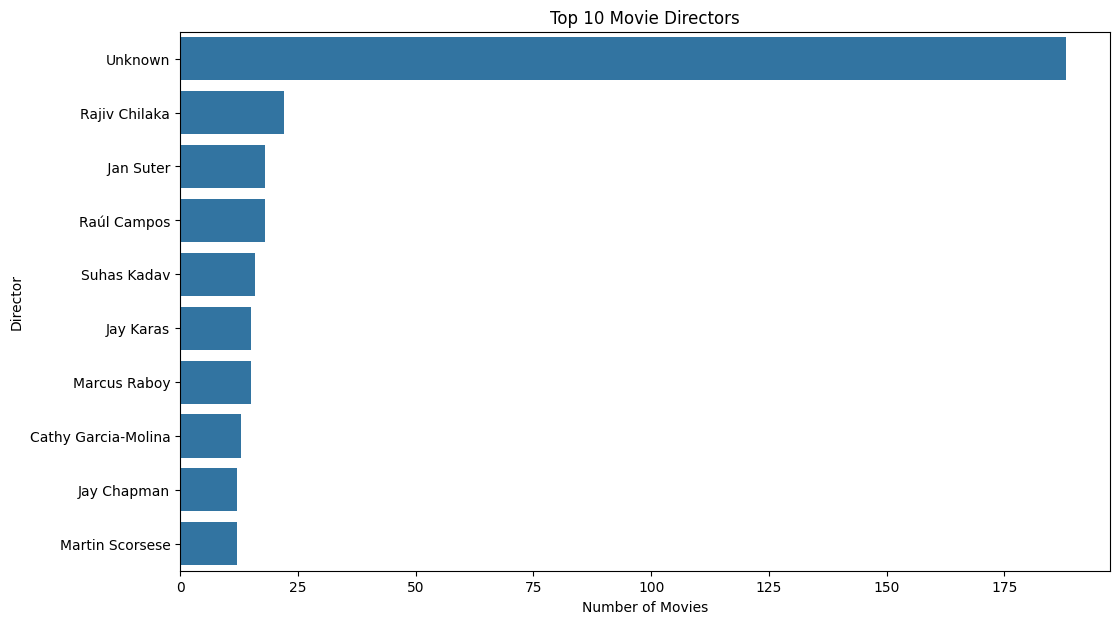

In [38]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_movie_directors.values, y=top_10_movie_directors.index)
plt.title('Top 10 Movie Directors')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

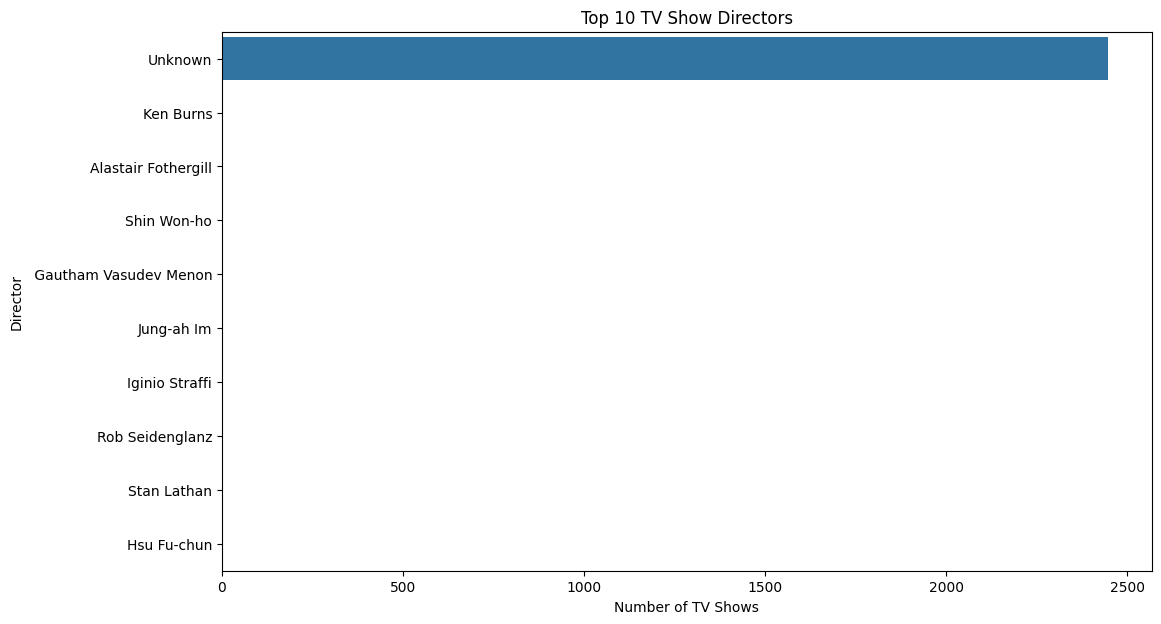

In [39]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_tv_show_directors.values, y=top_10_tv_show_directors.index)
plt.title('Top 10 TV Show Directors')
plt.xlabel('Number of TV Shows')
plt.ylabel('Director')
plt.show()

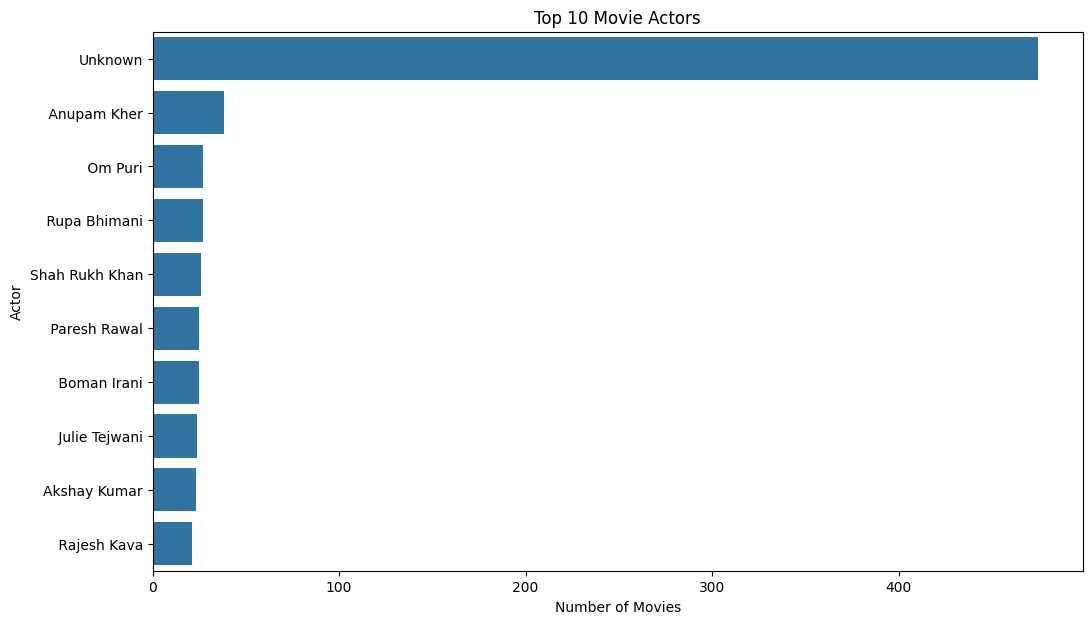

In [40]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_movie_actors.values, y=top_10_movie_actors.index)
plt.title('Top 10 Movie Actors')
plt.xlabel('Number of Movies')
plt.ylabel('Actor')
plt.show()

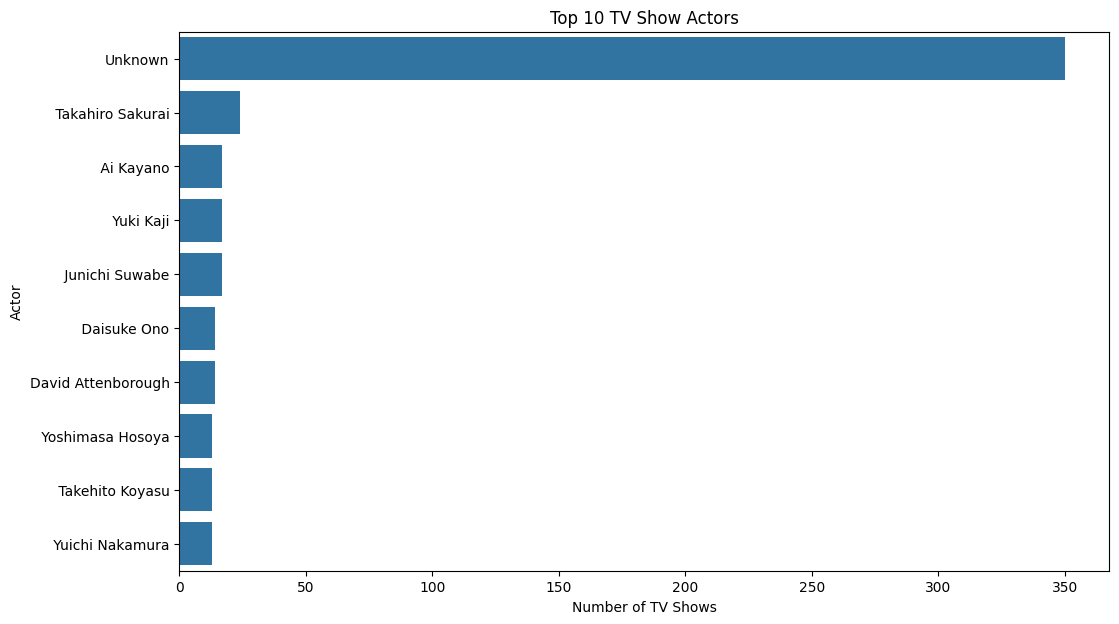

In [41]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_tv_show_actors.values, y=top_10_tv_show_actors.index)
plt.title('Top 10 TV Show Actors')
plt.xlabel('Number of TV Shows')
plt.ylabel('Actor')
plt.show()

**## Summary:**

**Data Analysis Key Findings**

*   The top 10 movie directors (excluding 'Unknown') include Rajiv Chilaka, Jan Suter, and Raúl Campos.
*   The top 10 TV show directors (excluding 'Unknown') include Ken Burns and Alastair Fothergill.
*   There is no overlap in the top 10 directors between movies and TV shows (excluding 'Unknown').
*   The top 10 movie actors (excluding 'Unknown') include Anupam Kher, Om Puri, and Rupa Bhimani.
*   The top 10 TV show actors (excluding 'Unknown') include Takahiro Sakurai, Ai Kayano, and Yuki Kaji.
*   There is no overlap in the top 10 actors between movies and TV shows (excluding 'Unknown').
*   A significant number of entries in both movie and TV show categories have missing director or cast information, represented by the "Unknown" category consistently appearing at the top of the lists.

**Insights or Next Steps**

*   The lack of overlap in the top 10 directors and actors between movies and TV shows suggests that Netflix may be utilizing different talent pools or that professionals tend to specialize in one format.
*   Investigating the content of the movies and TV shows associated with the top directors and actors could provide insights into the genres or types of productions they are most involved in.


**Problem Statement : Understanding what content is available in different countries**

**Reasoning**:
Group the data by country and count the number of titles in each country, then displayed the result.



In [42]:
country_counts = df.groupby('country').size()
display(country_counts)

/tmp/ipykernel_687/4078170671.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_counts = df.groupby('country').size()


,0
country,
", France, Algeria",1
", South Korea",1
Argentina,56
"Argentina, Brazil, France, Poland, Germany, Denmark",1
"Argentina, Chile",2
...,...
Venezuela,1
"Venezuela, Colombia",1
Vietnam,7


**Reasoning**:
Group the DataFrame by country and type, count the occurrences, unstack the type column, and fill NaN values with 0.



In [43]:
top_10_countries_content = df.groupby(['country', 'type']).size().unstack().fillna(0)
display(top_10_countries_content)

/tmp/ipykernel_687/3450276375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_countries_content = df.groupby(['country', 'type']).size().unstack().fillna(0)


type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,7,0


**Reasoning**:
Sort the `country_counts` Series in descending order and display the top 10 countries with the highest number of titles.



In [44]:
sorted_country_counts = country_counts.sort_values(ascending=False)
display(sorted_country_counts.head(10))

,0
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


**Reasoning**:
Summarize the key findings from the content distribution analysis by country based on the previous outputs.



In [45]:
print("Summary of Content Distribution by Country:")
print("-" * 45)


print("The countries with the highest overall content volume are:")
display(sorted_country_counts.head(10))

print("\nContent Type Distribution in Top Countries:")
print("Looking at the breakdown of Movies vs. TV Shows in the top countries:")
display(country_content.loc[sorted_country_counts.head(10).index])

Summary of Content Distribution by Country:
---------------------------------------------
The countries with the highest overall content volume are:


,0
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124



Content Type Distribution in Top Countries:
Looking at the breakdown of Movies vs. TV Shows in the top countries:


type,Movie,TV Show
country,,
United States,2058,760
India,893,79
Unknown,440,391
United Kingdom,206,213
Japan,76,169
South Korea,41,158
Canada,122,59
Spain,97,48
France,75,49


**## Summary:**


**Data Analysis Key Findings**

*   The United States has the highest overall content volume with 2818 titles, significantly exceeding other countries.
*   India ranks second in content volume with 972 titles.
*   A substantial amount of content (831 titles) is categorized as 'Unknown', indicating missing country information.
*   Among the top countries, the distribution of content types varies:
    *   The United States has a larger number of Movies than TV Shows.
    *   India's content is predominantly Movies.
    *   The United Kingdom, Japan, and South Korea also contribute a notable amount of content with varying proportions of Movies and TV Shows.

**Insights or Next Steps**

*   Investigate the 'Unknown' category to identify the countries of origin for this content and improve data completeness.
*   Further analyze the content type distribution in other countries beyond the top 10 to understand global trends.


**Problem Statement : Months & Titles V/S Country**


In [46]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month_added'] = df['date_added'].dt.month

country_month_counts = df.groupby(['country', 'month_added'], observed=False).size().unstack().fillna(0)
display(country_month_counts.head(10))

month_added,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
country,,,,,,,,,,,,
", France, Algeria",0,0,0,0,0,0,1,0,0,0,0,0
", South Korea",0,0,0,0,0,0,0,1,0,0,0,0
Argentina,5,4,4,4,6,6,6,6,3,5,5,2
"Argentina, Brazil, France, Poland, Germany, Denmark",0,0,0,1,0,0,0,0,0,0,0,0
"Argentina, Chile",0,1,0,0,0,0,0,0,0,0,1,0
"Argentina, Chile, Peru",0,0,0,0,0,0,1,0,0,0,0,0
"Argentina, France",0,0,0,0,0,0,0,1,0,0,0,0
"Argentina, France, United States, Germany, Qatar",0,0,0,0,0,0,1,0,0,0,0,0
"Argentina, Italy",0,0,0,0,1,0,0,0,0,0,0,0


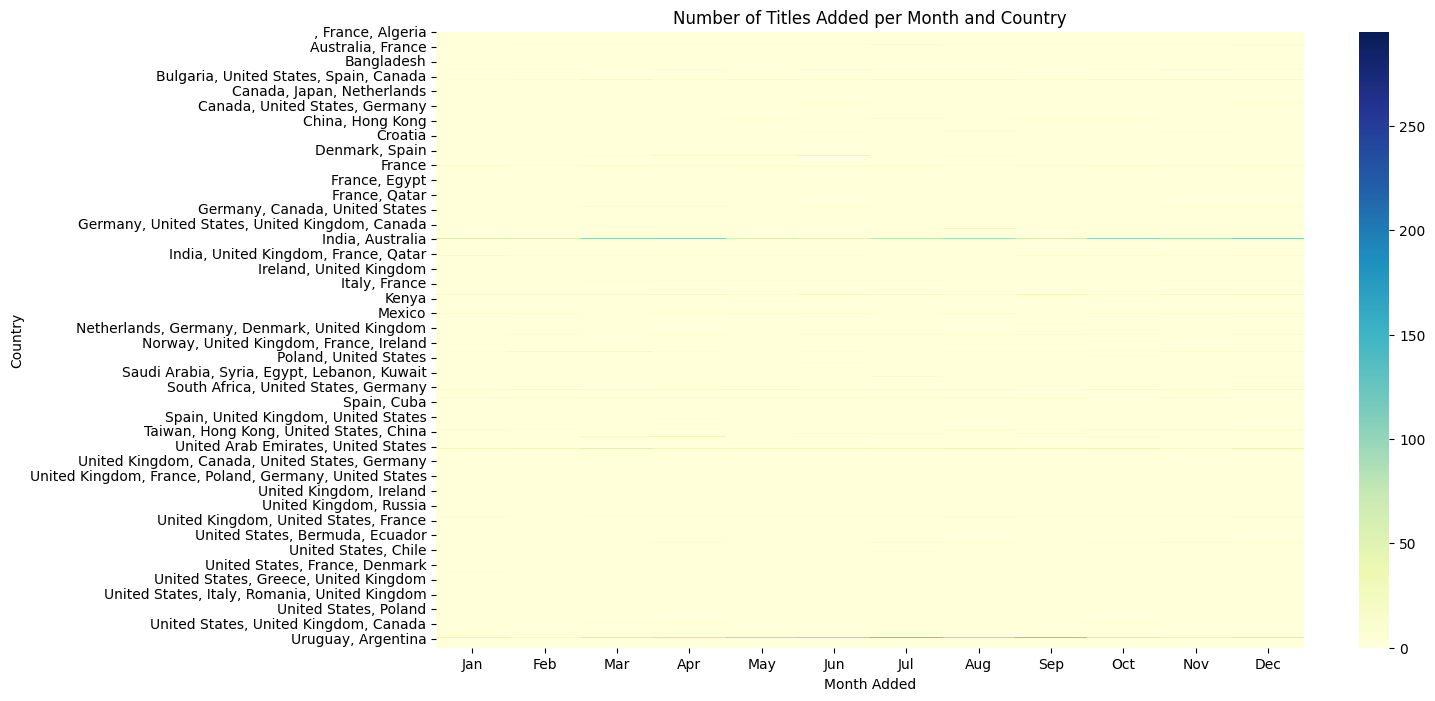

In [47]:
plt.figure(figsize=(14, 8))
sns.heatmap(country_month_counts, cmap='YlGnBu')
plt.title('Number of Titles Added per Month and Country')
plt.xlabel('Month Added')
plt.ylabel('Country')
plt.xticks(ticks=np.arange(12) + 0.5, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

**## Summary:**

**Data Analysis Key Findings**

* The analysis of `country_month_counts` and the heatmap revealed varying patterns of content additions across different countries throughout the year.
* Some countries, like the United States, appear to have a more consistent flow of content added across most months.
* Other countries might exhibit more seasonal trends, with certain months showing peaks in content additions.
* The heatmap clearly shows which country-month combinations have higher or lower volumes of new titles.

**Insights**

* Comparing the monthly patterns of different countries could highlight strategic differences in content rollout.

**## Overall Insights and Analysis of the Netflix Dataset**

Based on our analysis of the Netflix dataset, here are some key overall insights and findings:

**Content Distribution and Volume:**

*   The dataset contains information on a large number of titles (8807), with a significantly higher proportion of Movies (6131) compared to TV Shows (2676). This suggests that Netflix's content library is more heavily skewed towards movies.
*   The United States is the country with the highest overall content volume, followed by India and the United Kingdom. However, a considerable amount of content has an "Unknown" country of origin, highlighting a potential area for data improvement.
*   The distribution of content types varies across countries. While the US has more movies, other countries like the UK, Japan, and South Korea have a notable presence of both movies and TV shows, with varying proportions.

**Content Release Trends:**

*   Analyzing movie releases over the last 30 years shows a clear upward trend, with a significant increase in releases peaking around 2017-2018. There was a slight decline in the most recent years, potentially influenced by global events.
*   For TV shows, the analysis of release dates suggests that July and Fridays are historically popular times for launching new TV series on Netflix, based on the frequency of additions in the dataset.

**Talent Analysis (Directors and Actors):**

*   The analysis of top directors and actors revealed distinct sets of individuals for movies and TV shows, with no significant overlap in the top 10 lists (excluding the 'Unknown' category). This might indicate specialization in either movies or TV shows by the most prolific creators and performers on the platform.
*   The "Unknown" category for both directors and cast is prominent, indicating missing data that could provide further insights into the talent involved in a substantial portion of the content.

**Content Availability by Country and Month:**

*   The heatmap visualizing content additions by country and month shows diverse patterns. Some countries have a consistent flow of new content throughout the year, while others exhibit more seasonal trends. This could be influenced by local production schedules, holidays, or strategic release decisions by Netflix.

**Overall Implications:**

*   The dataset provides valuable insights into Netflix's content strategy, highlighting its focus on movies, the dominance of certain countries in content production, and trends in content releases over time.
*   Understanding the distribution of content by country and the timing of releases can be crucial for targeted marketing and content acquisition strategies.
*   Further investigation into the "Unknown" country and talent categories could enhance the completeness and depth of the analysis.
